In [1]:
import pandas as pd
import sqlite3

In [2]:
conn = sqlite3.connect('../data/checking-logs.sqlite')

cursor = conn.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = cursor.fetchall()

print("Таблицы в базе данных:")
for table in tables:
    print(table[0])


for table in tables:
    table_name = table[0]
    print(f"\nПоля в таблице {table_name}:")
    cursor.execute(f"PRAGMA table_info({table_name});")
    fields = cursor.fetchall()
    for field in fields:
        print(field)


pd.read_sql_query('SELECT * FROM pageviews', conn).info()

Таблицы в базе данных:
pageviews
checker
deadlines

Поля в таблице pageviews:
(0, 'index', 'INTEGER', 0, None, 0)
(1, 'uid', 'TEXT', 0, None, 0)
(2, 'datetime', 'TIMESTAMP', 0, None, 0)

Поля в таблице checker:
(0, 'index', 'INTEGER', 0, None, 0)
(1, 'status', 'TEXT', 0, None, 0)
(2, 'success', 'INTEGER', 0, None, 0)
(3, 'timestamp', 'TIMESTAMP', 0, None, 0)
(4, 'numTrials', 'INTEGER', 0, None, 0)
(5, 'labname', 'TEXT', 0, None, 0)
(6, 'uid', 'TEXT', 0, None, 0)

Поля в таблице deadlines:
(0, 'index', 'INTEGER', 0, None, 0)
(1, 'labs', 'TEXT', 0, None, 0)
(2, 'deadlines', 'INTEGER', 0, None, 0)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1080 entries, 0 to 1079
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   index     1080 non-null   int64 
 1   uid       1080 non-null   object
 2   datetime  1080 non-null   object
dtypes: int64(1), object(2)
memory usage: 25.4+ KB


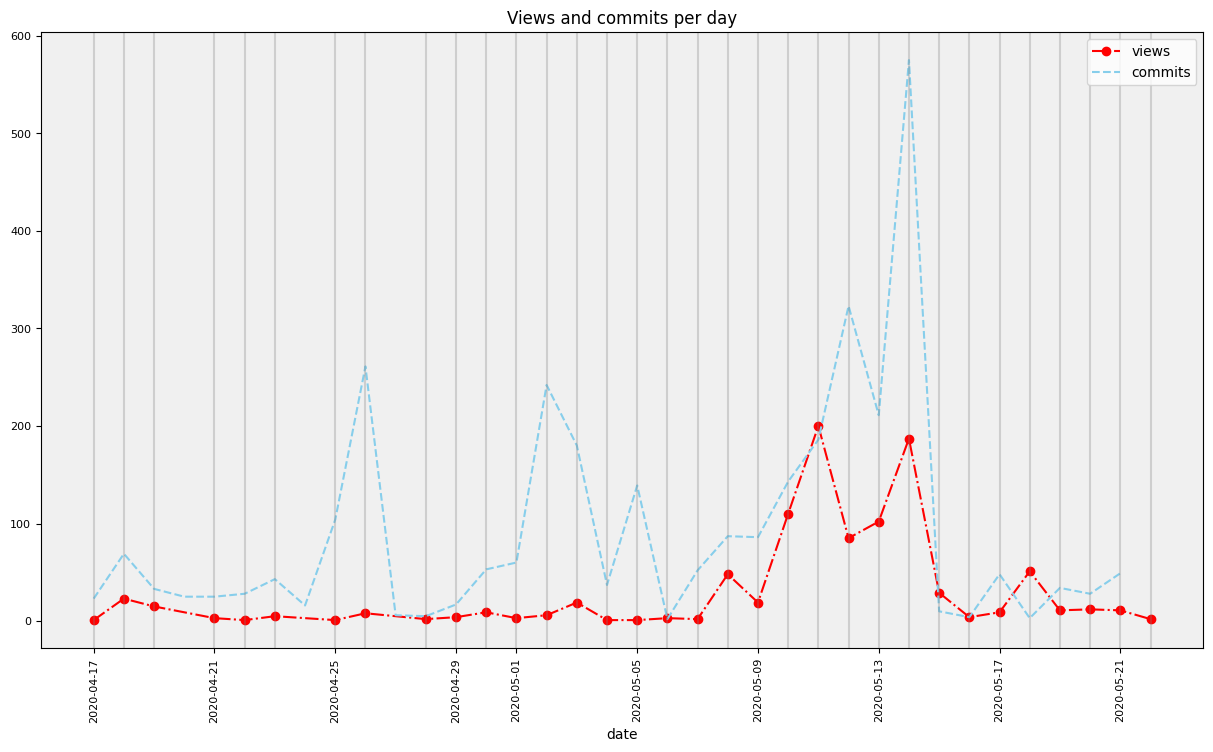

In [3]:
query_views = '''
SELECT 
    datetime
FROM
    pageviews
WHERE
    uid LIKE 'user%'
'''

query_commits = '''
SELECT 
    timestamp as commits
FROM
    checker
WHERE
    uid LIKE 'user%'
'''

df_views = pd.read_sql_query(query_views, conn)
df_views['datetime'] = pd.to_datetime(df_views['datetime'])
df_views['datetime'] = df_views['datetime'].dt.date
views_count = df_views.groupby('datetime').size().reset_index(name='views')


df_commits = pd.read_sql_query(query_commits, conn)
df_commits['commits'] = pd.to_datetime(df_commits['commits'])
df_commits['commits'] = df_commits['commits'].dt.date
commits_count = df_commits.groupby('commits').size()


ax = views_count.plot(
    kind='line', 
    fontsize=8,
    x='datetime',
    y='views',
    figsize=(15, 8),
    title='Views and commits per day',
    xlabel='date',
    rot = 90,
    style = 'r-.o',
    label = 'views'
)
commits_count.plot(
    kind='line', 
    fontsize=8,
    x='datetime',
    y='views',
    ax=ax,
    figsize=(15, 8),
    xlabel='date',
    rot = 90,
    style = '--',
    color = 'skyblue',
    label = 'commits'
)

ax.set_facecolor('#f0f0f0')

for x in views_count['datetime']:
    ax.axvline(x=x, color='gray', alpha=0.3)

ax.legend()

In [4]:
res = views_count[views_count['views'] > 150]
print(f"The answer is {res.shape[0]}")

The answer is 2


In [5]:
conn.close()